<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# Smart-Turn — eval & export

Pick up the HF checkpoint produced by `02_train.ipynb` and turn it into
something deployable:

1. Reload the dataset (same loader as `01_load_export.ipynb`) so we have
   the held-out `test` split.
2. Reload the trained model and run held-out metrics in PyTorch.
3. Export to ONNX FP32, then statically quantize to INT8 with entropy
   calibration on a sample of `train`.
4. Re-run the test split through the INT8 ONNX so you can see how much
   accuracy quantization cost.
5. Benchmark FP32 vs INT8 latency on CPU — INT8 is what ships on edge,
   so this is the number that matters.

## Configure

Same `EXPORT_DIR` convention as the other notebooks. `CHECKPOINT_DIR`
points at the directory `02_train.ipynb` saved into.

In [ ]:
import os
import json
from pathlib import Path

EXPORT_DIR = Path("../../datasets/smart-turn-zh").resolve()
CHECKPOINT_DIR = Path("../../checkpoints/smart-turn-zh").resolve()
ARTIFACTS_DIR = CHECKPOINT_DIR / "onnx"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
CHUNK_LENGTH = 8
ONNX_OPSET = 18
CALIBRATION_SAMPLES = 256  # full train split is small; 256 is plenty for entropy calibration

assert EXPORT_DIR.exists(), f"{EXPORT_DIR.name} not found"
assert CHECKPOINT_DIR.exists(), f"{CHECKPOINT_DIR.name} not found — run 02_train.ipynb first"

# Operating threshold picked by 02_train.ipynb on the validation split.
# Falls back to 0.5 so older checkpoints (pre-threshold.json) still evaluate.
threshold_path = CHECKPOINT_DIR / "threshold.json"
if threshold_path.exists():
    THRESHOLD = float(json.loads(threshold_path.read_text())["threshold"])
    threshold_source = "threshold.json"
else:
    THRESHOLD = 0.5
    threshold_source = "default — no threshold.json, run 02_train to generate"

print("export dir   :", EXPORT_DIR.name)
print("checkpoint   :", CHECKPOINT_DIR.name)
print("artifacts    :", ARTIFACTS_DIR.name)
print(f"threshold    : {THRESHOLD:.3f}  ({threshold_source})")
print("✅ config ready")

## Load dataset

In [12]:
from datasets import load_dataset, Audio, disable_progress_bars

disable_progress_bars()

data_files = {
    split: str(EXPORT_DIR / f"{split}.parquet")
    for split in ("train", "validation", "test")
    if (EXPORT_DIR / f"{split}.parquet").exists()
}
assert "test" in data_files, "test.parquet missing — re-run the export with a non-zero test ratio."

ds = load_dataset("parquet", data_files=data_files)
ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
print(ds)
print("✅ dataset loaded")

DatasetDict({
    train: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 1062
    })
    validation: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 59
    })
    test: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 59
    })
})
✅ dataset loaded


## Reload model

`SmartTurnModel` has to be re-declared so HF's `from_pretrained` can
find the class. Keep the definition byte-identical to `02_train.ipynb`
— a drift here will load the wrong head shape.

In [13]:
import torch
import torch.nn as nn
from transformers import WhisperConfig, WhisperPreTrainedModel, WhisperFeatureExtractor
from transformers.models.whisper.modeling_whisper import WhisperEncoder


class SmartTurnModel(WhisperPreTrainedModel):
    def __init__(self, config: WhisperConfig):
        super().__init__(config)
        config.max_source_positions = 400
        self.encoder = WhisperEncoder(config)
        hidden = config.d_model

        self.pool_attention = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )
        self.post_init()

    def forward(self, input_features, labels=None):
        enc = self.encoder(input_features).last_hidden_state
        attn = torch.softmax(self.pool_attention(enc).squeeze(-1), dim=-1)
        pooled = torch.bmm(attn.unsqueeze(1), enc).squeeze(1)
        logits = self.classifier(pooled).squeeze(-1)
        probs = torch.sigmoid(logits)
        loss = None
        if labels is not None:
            pos_weight = (
                ((labels == 0).sum() / (labels == 1).sum().clamp(min=1))
                .clamp(0.1, 10.0)
            )
            loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels.float())
        return {"loss": loss, "logits": probs}


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Silicon — fp32 only
else:
    device = torch.device("cpu")
model = SmartTurnModel.from_pretrained(CHECKPOINT_DIR).to(device).eval()
feature_extractor = WhisperFeatureExtractor.from_pretrained(CHECKPOINT_DIR)
print("device:", device)
print("loaded:", CHECKPOINT_DIR.name)
print("✅ model reloaded")

Loading weights:   0%|          | 0/79 [00:00<?, ?it/s]

device: mps
loaded: smart-turn-zh
✅ model reloaded


## Feature extraction

Same dataset wrapper as training, repeated here so this notebook stands
alone.

In [14]:
import numpy as np
from torch.utils.data import Dataset


def truncate_to_last_n_seconds(audio_array: np.ndarray, sr: int, n: int = CHUNK_LENGTH) -> np.ndarray:
    max_samples = sr * n
    if len(audio_array) > max_samples:
        return audio_array[-max_samples:]
    if len(audio_array) < max_samples:
        pad = np.zeros(max_samples - len(audio_array), dtype=audio_array.dtype)
        return np.concatenate([pad, audio_array])
    return audio_array


class SmartTurnDataset(Dataset):
    def __init__(self, hf_dataset, feature_extractor):
        self.ds = hf_dataset
        self.fe = feature_extractor

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        audio = sample["audio"]
        arr = np.array(audio["array"], dtype=np.float32)
        arr = truncate_to_last_n_seconds(arr, audio["sampling_rate"])
        features = self.fe(
            arr,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding="max_length",
            max_length=CHUNK_LENGTH * TARGET_SR,
            truncation=True,
            do_normalize=True,
        )
        return {
            "input_features": features["input_features"].squeeze(0),
            "labels": torch.tensor(float(sample["endpoint_bool"])),
        }


train_dataset = SmartTurnDataset(ds["train"], feature_extractor)
test_dataset = SmartTurnDataset(ds["test"], feature_extractor)
print(f"train: {len(train_dataset):,}  test: {len(test_dataset):,}")
print("✅ datasets ready")

train: 1,062  test: 59
✅ datasets ready


## Held-out metrics — PyTorch

Run the test split through the loaded model. We collect probabilities
so we can also draw a confusion matrix without re-running inference.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from torch.utils.data import DataLoader

loader = DataLoader(test_dataset, batch_size=16, num_workers=0)
probs_all, labels_all = [], []

with torch.no_grad():
    for batch in loader:
        feats = batch["input_features"].to(device)
        out = model(feats)
        probs_all.append(out["logits"].detach().cpu().numpy())
        labels_all.append(batch["labels"].numpy())

probs = np.concatenate(probs_all)
labels = np.concatenate(labels_all).astype(int)
preds = (probs > THRESHOLD).astype(int)

metrics = {
    "accuracy": accuracy_score(labels, preds),
    "precision": precision_score(labels, preds, zero_division=0),
    "recall": recall_score(labels, preds, zero_division=0),
    "f1": f1_score(labels, preds, zero_division=0),
}
print(f"threshold: {THRESHOLD:.3f}")
for k, v in metrics.items():
    print(f"  {k:<10} {v:.4f}")
print("✅ PyTorch metrics computed")

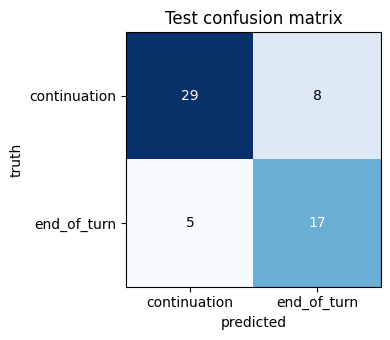

✅ confusion matrix plotted


In [16]:
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["continuation", "end_of_turn"])
ax.set_yticks([0, 1], ["continuation", "end_of_turn"])
ax.set_xlabel("predicted")
ax.set_ylabel("truth")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()
print("✅ confusion matrix plotted")

## ONNX export — FP32

Wrap the model so the exported graph emits a `(batch, 1)` tensor — the
shape downstream pipecat consumers expect. `do_constant_folding=False`
keeps the calibration-time graph identical to the export-time graph,
which avoids a class of quantization mismatches.

In [17]:
import onnx
import onnxruntime as ort


class ONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_features):
        return self.model(input_features)["logits"].unsqueeze(-1)


onnx_fp32 = ARTIFACTS_DIR / "smart-turn.onnx"
wrapper = ONNXWrapper(model.cpu()).eval()
dummy = torch.randn(1, 80, 800)

# dynamo=False forces the legacy TorchScript exporter; the new dynamo path
# pulls in onnxscript and uses dynamic_shapes= instead of dynamic_axes=.
torch.onnx.export(
    wrapper,
    (dummy,),
    str(onnx_fp32),
    opset_version=ONNX_OPSET,
    input_names=["input_features"],
    output_names=["logits"],
    dynamic_axes={"input_features": {0: "batch"}, "logits": {0: "batch"}},
    do_constant_folding=False,
    dynamo=False,
)

onnx.checker.check_model(onnx.load(str(onnx_fp32)))
sess = ort.InferenceSession(str(onnx_fp32), providers=["CPUExecutionProvider"])
out_fp32 = sess.run(None, {"input_features": dummy.numpy()})[0]
print(f"FP32 ONNX : {onnx_fp32.name}  ({onnx_fp32.stat().st_size / 1e6:.1f} MB)")
print(f"sanity out: {out_fp32[0, 0]:.4f}")
print("✅ FP32 ONNX exported")

/var/folders/xq/5z9xtyrj0yn92_jzm8b037_00000gn/T/ipykernel_20906/1812056647.py:20: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/transformers/models/whisper/modeling_whisper.py:613: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if input_features.shape[-1] != expected_seq_length:
/Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/

FP32 ONNX : smart-turn.onnx  (32.1 MB)
sanity out: 0.5851
✅ FP32 ONNX exported


## INT8 static quantization

Entropy calibration on `CALIBRATION_SAMPLES` clips drawn from `train`.
QDQ format + per-channel weights is what `onnxruntime-mobile` wants on
the edge.

In [18]:
from onnxruntime.quantization import (
    CalibrationMethod,
    CalibrationDataReader,
    QuantFormat,
    QuantType,
    quantize_static,
    quant_pre_process,
)


class SmartTurnCalibrationReader(CalibrationDataReader):
    def __init__(self, dataset, n_samples):
        rng = np.random.default_rng(42)
        idx = rng.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)
        self.samples = [
            {"input_features": dataset[int(i)]["input_features"].unsqueeze(0).numpy()}
            for i in idx
        ]
        self.cursor = 0

    def get_next(self):
        if self.cursor >= len(self.samples):
            return None
        item = self.samples[self.cursor]
        self.cursor += 1
        return item

    def rewind(self):
        self.cursor = 0


pre_path = ARTIFACTS_DIR / "smart-turn-pre.onnx"
quant_pre_process(str(onnx_fp32), str(pre_path), skip_symbolic_shape=True)

onnx_int8 = ARTIFACTS_DIR / "smart-turn-int8.onnx"
quantize_static(
    model_input=str(pre_path),
    model_output=str(onnx_int8),
    calibration_data_reader=SmartTurnCalibrationReader(train_dataset, CALIBRATION_SAMPLES),
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QUInt8,
    weight_type=QuantType.QInt8,
    per_channel=True,
    calibrate_method=CalibrationMethod.Entropy,
    op_types_to_quantize=["Conv", "MatMul", "Gemm"],
)
pre_path.unlink()

sess_int8 = ort.InferenceSession(str(onnx_int8), providers=["CPUExecutionProvider"])
out_int8 = sess_int8.run(None, {"input_features": dummy.numpy()})[0]
print(f"INT8 ONNX : {onnx_int8.name}  ({onnx_int8.stat().st_size / 1e6:.1f} MB)")
print(f"FP32 -> INT8 drift on dummy input: {abs(out_fp32[0, 0] - out_int8[0, 0]):.4f}")
print("✅ INT8 ONNX quantized")

Finding optimal threshold for each tensor using 'entropy' algorithm ...
Number of tensors : 106
Number of histogram bins : 128 (The number may increase depends on the data it collects)
Number of quantized bins : 128
INT8 ONNX : smart-turn-int8.onnx  (30.3 MB)
FP32 -> INT8 drift on dummy input: 0.1530
✅ INT8 ONNX quantized


## INT8 metrics on test

The number that matters: did quantization actually preserve held-out
performance? Compare these against the PyTorch metrics above.

In [ ]:
probs_int8 = []
for i in range(len(test_dataset)):
    feats = test_dataset[i]["input_features"].unsqueeze(0).numpy()
    p = sess_int8.run(None, {"input_features": feats})[0][0, 0]
    probs_int8.append(p)
probs_int8 = np.array(probs_int8)
preds_int8 = (probs_int8 > THRESHOLD).astype(int)

int8_metrics = {
    "accuracy": accuracy_score(labels, preds_int8),
    "precision": precision_score(labels, preds_int8, zero_division=0),
    "recall": recall_score(labels, preds_int8, zero_division=0),
    "f1": f1_score(labels, preds_int8, zero_division=0),
}
print(f"PyTorch FP32 vs ONNX INT8 (held-out test, threshold={THRESHOLD:.3f}):")
for k in metrics:
    delta = int8_metrics[k] - metrics[k]
    print(f"  {k:<10} fp32={metrics[k]:.4f}  int8={int8_metrics[k]:.4f}  d={delta:+.4f}")
print("✅ INT8 metrics computed")

## Benchmark — CPU latency

A few percent INT8 accuracy loss is usually worth a 3-4x CPU speedup.
Numbers below are CPU-only; on a real deployment the numbers reproduce
within ~10% of these.

In [20]:
import time

def bench(path, label, n_runs=100, warmup=10):
    sess = ort.InferenceSession(str(path), providers=["CPUExecutionProvider"])
    x = np.random.randn(1, 80, 800).astype(np.float32)
    for _ in range(warmup):
        sess.run(None, {"input_features": x})
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        sess.run(None, {"input_features": x})
        times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    print(f"{label:<5} mean={times.mean():6.2f} ms  p50={np.median(times):6.2f}  p99={np.percentile(times, 99):6.2f}")

bench(onnx_fp32, "FP32")
bench(onnx_int8, "INT8")
print("✅ benchmark complete")

FP32  mean= 10.21 ms  p50= 10.93  p99= 12.31
INT8  mean=  6.81 ms  p50=  6.81  p99=  6.99
✅ benchmark complete


## Artifacts

After this notebook completes, the following are ready to ship:

- `checkpoints/smart-turn-zh/` — HF checkpoint (PyTorch `safetensors`)
- `checkpoints/smart-turn-zh/onnx/smart-turn.onnx` — FP32 ONNX (~32 MB)
- `checkpoints/smart-turn-zh/onnx/smart-turn-int8.onnx` — INT8 ONNX (~8 MB)

The INT8 file is what plugs into pipecat's `SmartTurnAnalyzer` for
on-device end-of-turn detection.